In [ ]:
# from langchain_groq import ChatGroq
from typing import TypedDict
from langgraph.graph import StateGraph ,START,END
# Define State
class MyBank(TypedDict):
    name:str
    balance:float
    taxes:float
    profit:float
    category:str

def my_bank_profit(state:MyBank)->MyBank:
    balance = state["balance"]
    taxes = state["taxes"]
    profit = balance - taxes
    state['profit'] = profit
    return state

def label_it(state: MyBank) -> MyBank:
    profit = state['profit']
    if profit >= 45000:
        state['category'] = "Maximum Profit"
    elif profit >= 25000:
        state['category'] = "Medium Profit"
    elif profit >= 10000:
        state['category'] = "Minimum Profit"
    else:
        state['category'] = "Low Profit"

    return state


{'name': 'Badmosh', 'balance': 100000.0, 'taxes': 95000.0, 'profit': 5000.0, 'category': 'Low Profit'}


In [ ]:
# setup graph
graph = StateGraph(MyBank)

# add nodes to your graph
graph.add_node("my_bank_profit",my_bank_profit)
graph.add_node("label_it",label_it)


# add  edges to your graph
graph.add_edge(START,'my_bank_profit')
graph.add_edge('my_bank_profit','label_it')
graph.add_edge('label_it',END)

In [ ]:
# compile the graph
workflow = graph.compile()

In [ ]:
# execute the graph
initial_state: MyBank = {
    "name": "Badmosh",
    "balance": 100000.0,
    "taxes": 95000.0,
    "profit": 0.0,
    "category": ""

}
final_state = workflow.invoke(initial_state)
print(final_state)

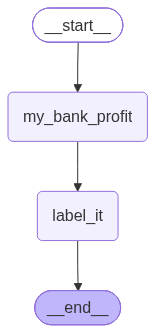

In [5]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())